In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X = data.data           # data.data contains all the input features
y = data.target         # data.target contains the output values

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
L = LinearRegression()

In [7]:
L.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
print(L.coef_)
print(L.intercept_)

[  47.74968054 -241.99090728  531.97106288  381.56286182 -918.50290455
  508.25778252  116.95016447  269.4923028   695.80811712   26.32458203]
151.6651755919933


In [9]:
y_pred = L.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

print("R2 score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 score: 0.4849058889476757
Mean Squared Error: 2848.3106508475043


In [11]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=100000)
# alpha controls the amount of regularization (penalty)
# Higher alpha → simpler model, less overfitting
# Lower alpha → model behaves more like Linear Regression

In [12]:
R.fit(X_train, y_train)

,alpha,100000
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [13]:
print(R.coef_)
print(R.intercept_)

[ 0.00236402  0.00017083  0.00717334  0.00543602  0.0022552   0.00182513
 -0.0048055   0.00526574  0.0065972   0.00452279]
154.3443497850259


In [14]:
y_pred1 = R.predict(X_test)

In [15]:
print("R2 score", r2_score(y_test, y_pred1))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score -0.01399268993978997
RMSE 53.36956671032195


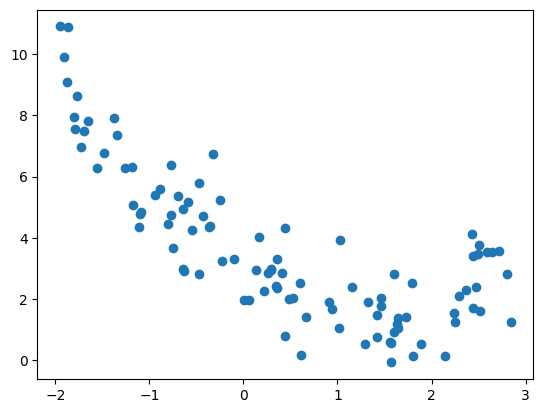

In [16]:
# Number of data points
m = 100

# Generate 100 random values between -2 and 3
x1 = 5 * np.random.rand(m, 1) - 2

# Create a non-linear (quadratic) relationship with random noise
# x2 = 0.7x1² - 2x1 + 3 + Noise
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

# Plot the generated data points
plt.scatter(x1, x2)

# Display the graph
plt.show()

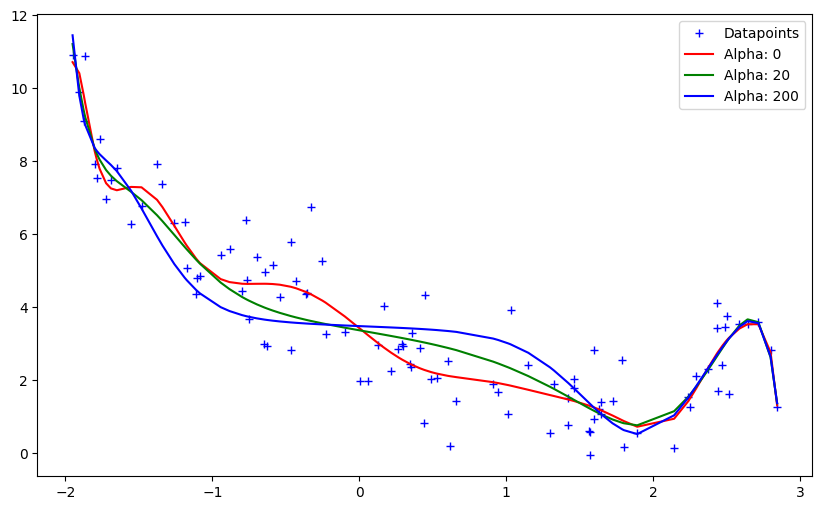

In [ ]:
from sklearn.pipeline import Pipeline
# Import Pipeline to combine preprocessing and model training into one workflow

from sklearn.preprocessing import PolynomialFeatures
# Import PolynomialFeatures to create polynomial features (X², X³, ...)


# Function to train a Polynomial Ridge Regression model and return predictions
def get_preds_ridge(x1, x2, alpha):

    # Create a pipeline:
    # Step 1 → Generate polynomial features (up to degree 16)
    # Step 2 → Apply Ridge Regression with the given alpha
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])

    # Train the pipeline on the given dataset
    model.fit(x1, x2)

    # Return predicted values
    return model.predict(x1)


# Different alpha (regularization) values to compare
alphas = [0, 20, 200]

# Colors for each prediction curve
cs = ['r', 'g', 'b']


# Create a figure of size 10 × 6
plt.figure(figsize=(10, 6))

# Plot the original data points
plt.plot(x1, x2, 'b+', label='Datapoints')


# Train and plot a curve for each alpha value
for alpha, c in zip(alphas, cs):

    # Get predictions using the current alpha value
    preds = get_preds_ridge(x1, x2, alpha)

    # Plot the prediction curve
    # sorted(x1[:,0]) -> Sort X values for a smooth curve
    # np.argsort(x1[:,0]) -> Arrange predictions in the same sorted order
    plt.plot(
        sorted(x1[:, 0]),
        preds[np.argsort(x1[:, 0])],
        c,
        label='Alpha: {}'.format(alpha)
    )


# Display legend (Alpha = 0, 20, 200)
plt.legend()

# Display the graph
plt.show()